Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

Load Dataset

In [ ]:
trades = pd.read_csv("historical_data.csv")

/tmp/ipykernel_5319/822699516.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


Inspect Dataset

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,895000000000000.0,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,443000000000000.0,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,660000000000000.0,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1080000000000000.0,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1050000000000000.0,1.730000e+12


In [ ]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41760 entries, 0 to 41759
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           41760 non-null  object 
 1   Coin              41760 non-null  object 
 2   Execution Price   41760 non-null  float64
 3   Size Tokens       41760 non-null  float64
 4   Size USD          41760 non-null  float64
 5   Side              41760 non-null  object 
 6   Timestamp IST     41760 non-null  object 
 7   Start Position    41760 non-null  float64
 8   Direction         41760 non-null  object 
 9   Closed PnL        41760 non-null  float64
 10  Transaction Hash  41760 non-null  object 
 11  Order ID          41760 non-null  int64  
 12  Crossed           41760 non-null  bool   
 13  Fee               41760 non-null  float64
 14  Trade ID          41760 non-null  object 
 15  Timestamp         41759 non-null  float64
dtypes: bool(1), float64(7), int64(1), object

In [ ]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


Rename Columns

In [ ]:
trades = trades.rename(columns={
    'Account':'account',
    'Coin':'coin',
    'Execution Price':'execution_price',
    'Size Tokens':'size_tokens',
    'Size USD':'size_usd',
    'Side':'side',
    'Closed PnL':'closed_pnl',
    'Timestamp IST':'timestamp'
})

In [ ]:
trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp,Start Position,Direction,closed_pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,895000000000000.0,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,443000000000000.0,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,660000000000000.0,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1080000000000000.0,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1050000000000000.0,1.730000e+12


Convert Timestamp

In [ ]:
trades['timestamp'] = pd.to_datetime(
    trades['timestamp'],
    dayfirst=True
)

In [ ]:
trades['timestamp'] = pd.to_datetime(
    trades['timestamp'],
    format='%d-%m-%Y %H:%M'
)

In [ ]:
print(trades['timestamp'].head(10))

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
5   2024-12-02 22:50:00
6   2024-12-02 22:50:00
7   2024-12-02 22:50:00
8   2024-12-02 22:50:00
9   2024-12-02 22:50:00
Name: timestamp, dtype: datetime64[ns]


In [ ]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'])

In [ ]:
trades['date'] = trades['timestamp'].dt.date

Check Missing Values

In [ ]:
trades.isnull().sum()

,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp,0
Start Position,0
Direction,0
closed_pnl,0


In [ ]:
trades.describe()

,execution_price,size_tokens,size_usd,timestamp,Start Position,closed_pnl,Order ID,Fee,Timestamp
count,41760.000000,4.176000e+04,4.176000e+04,41760,4.176000e+04,41760.000000,4.176000e+04,41760.000000,4.175900e+04
mean,33687.863120,1.383980e+04,1.641800e+04,2024-12-23 06:49:44.889367808,-6.343195e+02,102.372872,6.334749e+10,3.317207,1.735138e+12
min,0.000010,1.000000e-05,0.000000e+00,2023-12-05 03:11:00,-1.433463e+07,-117990.104100,4.064961e+09,-1.175712,1.700000e+12
25%,4.148100,1.200600e-01,3.663525e+02,2024-12-10 03:05:30,-6.258423e+01,0.000000,5.403345e+10,0.015267,1.730000e+12
50%,2365.800000,2.437150e+00,1.528200e+03,2025-02-12 06:09:00,3.136395e+00,0.000000,7.161086e+10,0.199566,1.740000e+12
75%,85056.000000,1.941125e+02,9.999420e+03,2025-04-13 05:08:00,3.913136e+02,16.869169,8.611913e+10,2.034971,1.740000e+12
max,108410.000000,1.150000e+07,3.921431e+06,2025-05-01 11:42:00,1.150000e+07,135329.090100,9.014923e+10,837.471593,1.750000e+12
std,42573.040275,1.939097e+05,7.575351e+04,NaN,6.539555e+05,1567.057888,2.682354e+10,13.085900,1.338169e+10


Create Win/Loss Feature

In [ ]:
trades['win_trade'] = np.where(
    trades['closed_pnl'] > 0,
    1,
    0
)

In [ ]:
trades[['closed_pnl','win_trade']].head()

,closed_pnl,win_trade
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


Overall Win Rate

In [ ]:
win_rate = trades['win_trade'].mean()*100

print(f"Win Rate: {win_rate:.2f}%")

Win Rate: 47.19%


Total Profit/Loss

In [ ]:
total_pnl = trades['closed_pnl'].sum()

print("Total PnL:", total_pnl)

Total PnL: 4275091.141343


Profit Distribution

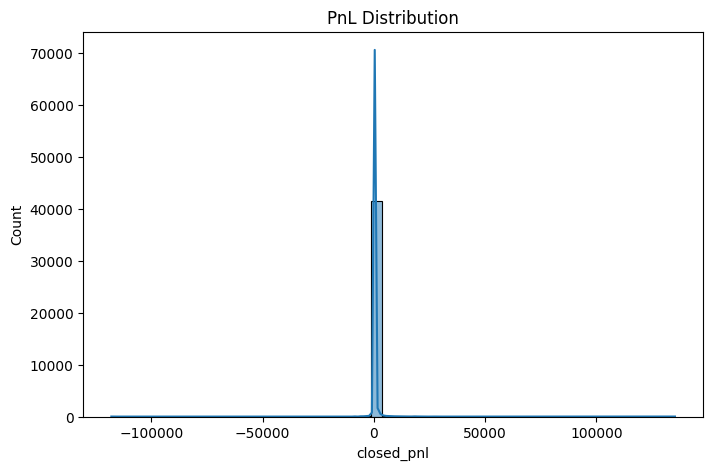

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    trades['closed_pnl'],
    bins=50,
    kde=True
)

plt.title("PnL Distribution")
plt.show()

Buy vs Sell Trades

In [ ]:
trades['side'].value_counts()

,count
side,
BUY,21066
SELL,20694


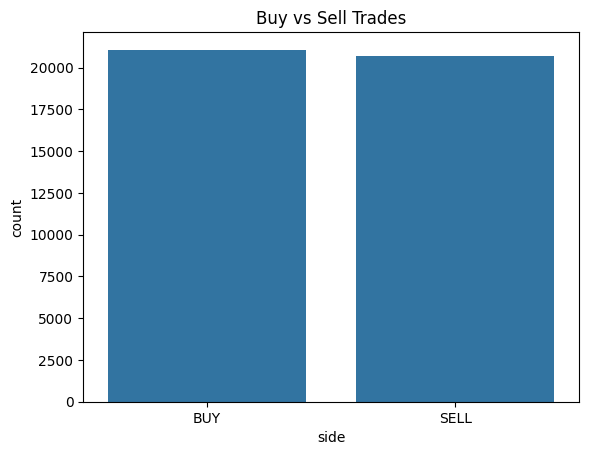

In [ ]:
sns.countplot(
    data=trades,
    x='side'
)

plt.title("Buy vs Sell Trades")
plt.show()

Coin-wise Trading Activity

In [ ]:
coin_count = trades['coin'].value_counts()

print(coin_count.head(10))

coin
BTC        16077
ETH         5859
SOL         2837
@107        2546
HYPE        1352
JELLY        992
ZEREBRO      644
PURR         629
LAYER        472
BERA         466
Name: count, dtype: int64


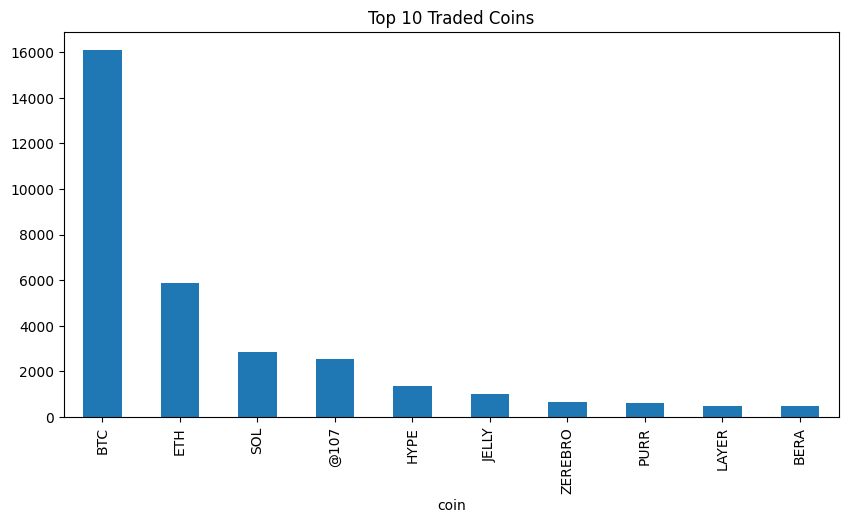

In [ ]:
coin_count.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Traded Coins")
plt.show()

Coin-wise Profitability

In [ ]:
coin_profit = trades.groupby(
    'coin'
)['closed_pnl'].sum().sort_values(
    ascending=False
)

print(coin_profit.head(10))

coin
SOL      1.081036e+06
BTC      8.340386e+05
ETH      8.042043e+05
@107     3.595106e+05
HYPE     3.024418e+05
ZRO      1.850999e+05
BERA     8.563424e+04
EIGEN    5.116399e+04
AIXBT    4.935648e+04
AVAX     4.781281e+04
Name: closed_pnl, dtype: float64


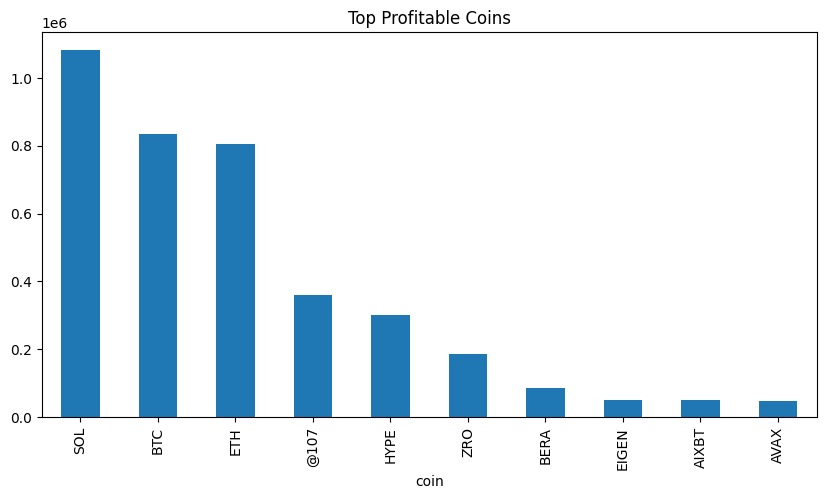

In [ ]:
coin_profit.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Profitable Coins")
plt.show()

Top 10 Traders

In [ ]:
top_traders = trades.groupby(
    'account'
)['closed_pnl'].sum().sort_values(
    ascending=False
)

top_traders.head(10)

,closed_pnl
account,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04
0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04


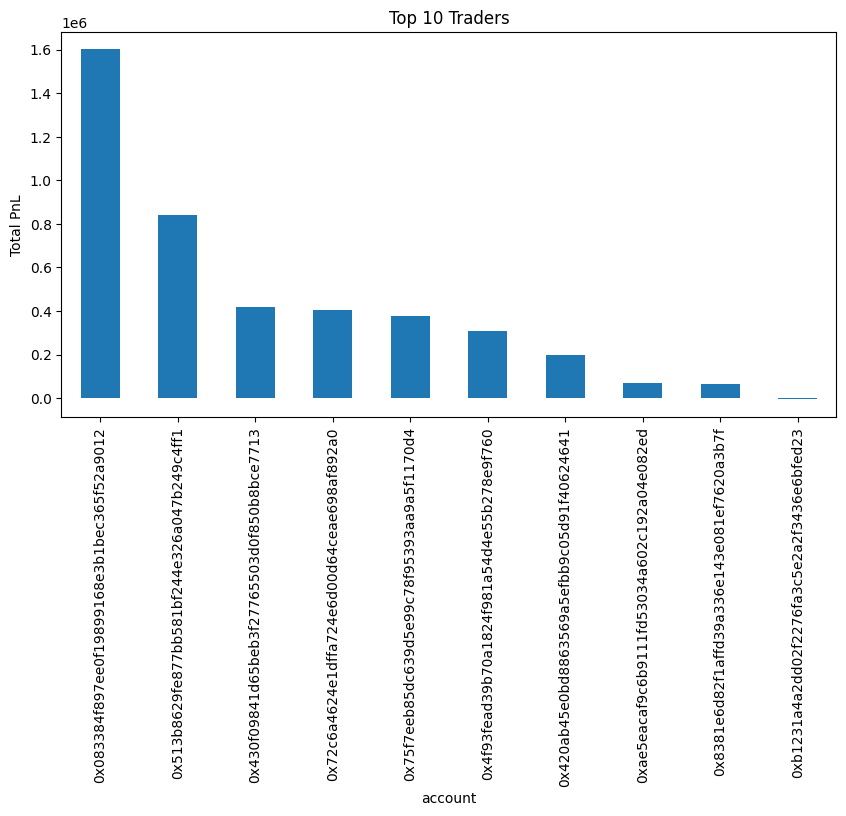

In [ ]:
top_traders.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Traders")
plt.ylabel("Total PnL")
plt.show()

In [ ]:
worst_traders = trades.groupby(
    'account'
)['closed_pnl'].sum().sort_values()

worst_traders.head(10)

,closed_pnl
account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-6.050757e+03
0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05


Worst 10 Traders

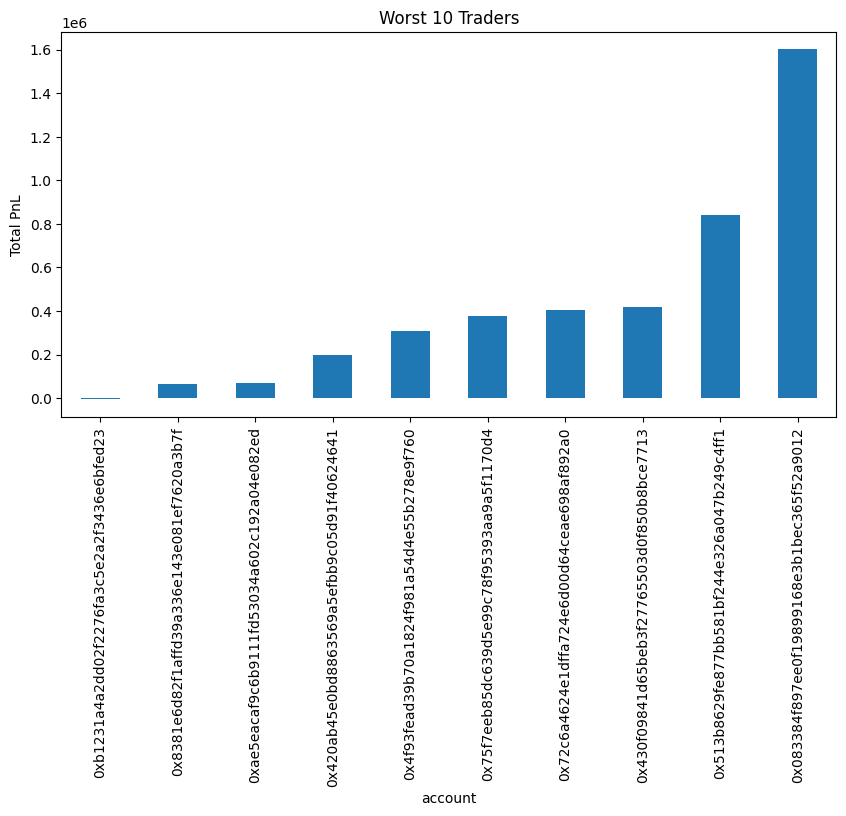

In [ ]:
worst_traders.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Worst 10 Traders")
plt.ylabel("Total PnL")
plt.show()

Trade Volume Analysis

In [ ]:
trades['size_usd'].describe()

,size_usd
count,4.176000e+04
mean,1.641800e+04
std,7.575351e+04
min,0.000000e+00
25%,3.663525e+02
50%,1.528200e+03
75%,9.999420e+03
max,3.921431e+06


In [ ]:
print("Average Trade Size USD:",
      trades['size_usd'].mean())

Average Trade Size USD: 16417.996367816093


Daily Profit Trend

In [ ]:
daily_profit = trades.groupby(
    'date'
)['closed_pnl'].sum().reset_index()

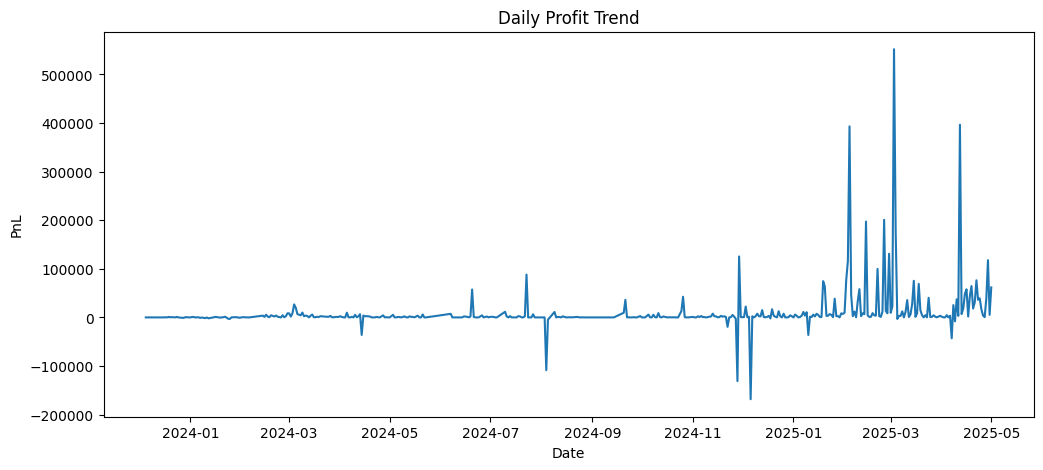

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_profit['date'],
    daily_profit['closed_pnl']
)

plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.show()

Side vs Profitability

In [ ]:
trades.groupby(
    'side'
)['closed_pnl'].mean()

,closed_pnl
side,
BUY,117.063154
SELL,87.418514


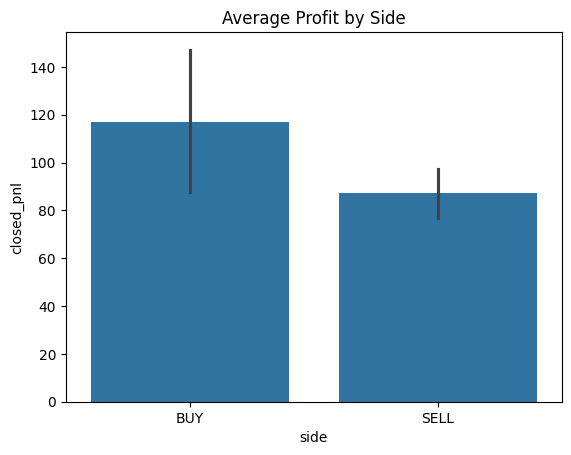

In [ ]:
sns.barplot(
    data=trades,
    x='side',
    y='closed_pnl'
)

plt.title("Average Profit by Side")
plt.show()